In [2]:
!pip install torch transformers datasets evaluate seqeval scikit-learn pandas numpy seaborn matplotlib sentencepiece accelerate

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 2.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 5.4 MB/s eta 0:00:00
  Created wheel for seqeval: filename=seqeval-1.2.2-py3-none-any.whl size=16162 sha256=131a95fed73933f18d058a48ca61397476084b65e6ed8de95dca175ec3442c98
  Stored in directory: /root/.cache/pip/wheels/5f/b8/73/0b2c1a76b701a677653dd79ece07cfabd7457989dbfbdcd8d7
Successfully built seqeval


In [3]:
!pip install evaluate seqeval

In [4]:
import ast
from collections import Counter

import torch
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from torch.utils.data import DataLoader
from datasets import Dataset
import evaluate
from transformers import (
    AutoTokenizer,
    AutoModelForTokenClassification,
    Trainer,
    TrainingArguments,
    DataCollatorForTokenClassification,
    EarlyStoppingCallback
)

In [5]:
df = pd.read_csv("final_data_BIO_v2.csv")
df["Tokenized_Text"] = df["Tokenized_Text"].apply(ast.literal_eval)
df["NER_Label_Sequence"] = df["NER_Label_Sequence"].apply(ast.literal_eval)

In [6]:
label_counter = Counter()
for seq in df["NER_Label_Sequence"]:
    label_counter.update(seq)

total_tokens = sum(label_counter.values())

print("\nWord-level label distribution (BEFORE split):")
for label, count in label_counter.most_common():
    print(f"{label:10s}: {count:7d} ({count/total_tokens:.2%})")



Word-level label distribution (BEFORE split):
O         :  385966 (96.62%)
I-SYMPTOM :    2954 (0.74%)
B-SYMPTOM :    2631 (0.66%)
B-DISEASE_DISORDER:    2036 (0.51%)
I-DISEASE_DISORDER:    1908 (0.48%)
B-MEDICATION:    1412 (0.35%)
I-PROCEDURE_TEST:    1048 (0.26%)
B-PROCEDURE_TEST:     772 (0.19%)
I-MEDICATION:     720 (0.18%)
B-HORMONE :       2 (0.00%)


In [7]:
import random
from collections import Counter


def downsample_O(tokens, labels, keep_ratio=0.005):
    new_tokens = []
    new_labels = []
    for t, l in zip(tokens, labels):
        if l == "O":
            if random.random() < keep_ratio:  # keep only a fraction of O
                new_tokens.append(t)
                new_labels.append(l)
        else:
            new_tokens.append(t)
            new_labels.append(l)
    return new_tokens, new_labels

df_downsampled = df.copy()
new_tokenized = []
new_labels = []

for t_seq, l_seq in zip(df_downsampled["Tokenized_Text"], df_downsampled["NER_Label_Sequence"]):
    t_new, l_new = downsample_O(t_seq, l_seq, keep_ratio=0.005)

    if len(t_new) > 0:
        new_tokenized.append(t_new)
        new_labels.append(l_new)

df_downsampled = pd.DataFrame({
    "Tokenized_Text": new_tokenized,
    "NER_Label_Sequence": new_labels
}).reset_index(drop=True)

label_counter = Counter()
for seq in df_downsampled["NER_Label_Sequence"]:
    label_counter.update(seq)

total_tokens = sum(label_counter.values())

print("\nWord-level label distribution AFTER aggressive O downsampling:")
for label, count in label_counter.most_common():
    print(f"{label:10s}: {count:7d} ({count/total_tokens:.2%})")



Word-level label distribution AFTER aggressive O downsampling:
I-SYMPTOM :    2954 (19.23%)
B-SYMPTOM :    2631 (17.12%)
B-DISEASE_DISORDER:    2036 (13.25%)
I-DISEASE_DISORDER:    1908 (12.42%)
O         :    1881 (12.24%)
B-MEDICATION:    1412 (9.19%)
I-PROCEDURE_TEST:    1048 (6.82%)
B-PROCEDURE_TEST:     772 (5.02%)
I-MEDICATION:     720 (4.69%)
B-HORMONE :       2 (0.01%)


In [9]:
import time
import torch
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
from datasets import Dataset
import evaluate
from transformers import (
    AutoTokenizer,
    AutoModelForTokenClassification,
    Trainer,
    TrainingArguments,
    EarlyStoppingCallback
)

# ==========================================
# 1. SETUP & DATA PREPARATION
# ==========================================

# Create Label Mappings (Global)
# We do this once so all models share the exact same ID structure
labels_list = list({l for seq in df_downsampled['NER_Label_Sequence'] for l in seq})
labels_list.sort()
label2id = {l: i for i, l in enumerate(labels_list)}
id2label = {i: l for l, i in label2id.items()}

print(f"Labels found: {labels_list}")

# Train-test split
train_df, test_df = train_test_split(df_downsampled, test_size=0.3, random_state=42)

# Convert to Hugging Face Dataset
raw_train_dataset = Dataset.from_pandas(train_df)
raw_test_dataset = Dataset.from_pandas(test_df)

# Load Metric (SeqEval)
metric = evaluate.load("seqeval")

def compute_metrics(p):
    predictions, labels = p
    predictions = np.argmax(predictions, axis=2)

    # Filter out ignored tokens (-100)
    true_labels = [[id2label[l] for l in label if l != -100] for label in labels]
    true_predictions = [[id2label[p] for (p, l) in zip(prediction, label) if l != -100]
                        for prediction, label in zip(predictions, labels)]

    results = metric.compute(predictions=true_predictions, references=true_labels)
    return {
        "precision": results["overall_precision"],
        "recall": results["overall_recall"],
        "f1": results["overall_f1"],
        "accuracy": results["overall_accuracy"],
    }

# ==========================================
# 2. MODULAR TRAINING FUNCTION
# ==========================================

def train_and_evaluate(model_checkpoint, train_ds, test_ds):
    print(f"\n{'='*40}")
    print(f"🚀 Processing Model: {model_checkpoint}")
    print(f"{'='*40}")

    start_time = time.time()

    # A. Tokenizer (Specific to each model)
    tokenizer = AutoTokenizer.from_pretrained(model_checkpoint, use_fast=True)

    # B. Alignment Logic
    def tokenize_and_align_labels(examples):
        tokenized_inputs = tokenizer(
            examples['Tokenized_Text'],
            truncation=True,
            padding='max_length',
            max_length=512,
            is_split_into_words=True
        )

        all_labels = []
        for i, seq_labels in enumerate(examples['NER_Label_Sequence']):
            word_ids = tokenized_inputs.word_ids(batch_index=i)
            label_ids = []
            previous_word_idx = None
            for word_idx in word_ids:
                if word_idx is None:
                    label_ids.append(-100)
                elif word_idx != previous_word_idx:
                    label_ids.append(label2id[seq_labels[word_idx]])
                else:
                    label_ids.append(-100) # Ignore subwords
                previous_word_idx = word_idx
            all_labels.append(label_ids)

        tokenized_inputs["labels"] = all_labels
        return tokenized_inputs

    # Apply Tokenization
    tokenized_train = train_ds.map(tokenize_and_align_labels, batched=True)
    tokenized_test = test_ds.map(tokenize_and_align_labels, batched=True)

    tokenized_train.set_format("torch")
    tokenized_test.set_format("torch")

    # C. Model Init
    model = AutoModelForTokenClassification.from_pretrained(
        model_checkpoint,
        num_labels=len(labels_list),
        id2label=id2label,
        label2id=label2id
    )

    # D. Arguments (Includes Early Stopping Config)
    training_args = TrainingArguments(
        output_dir=f"./results_{model_checkpoint.replace('/', '-')}",
        eval_strategy="epoch",
        save_strategy="epoch",
        load_best_model_at_end=True,
        metric_for_best_model="f1",
        greater_is_better=True,
        learning_rate=2e-5,
        per_device_train_batch_size=8,  # Adjust based on your GPU RAM
        per_device_eval_batch_size=8,
        num_train_epochs=10,            # Max epochs
        weight_decay=0.01,
        save_total_limit=1,
        logging_dir=f"./logs_{model_checkpoint.replace('/', '-')}",
        report_to="none"
    )

    # E. Trainer
    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=tokenized_train,
        eval_dataset=tokenized_test,
        tokenizer=tokenizer,
        compute_metrics=compute_metrics,
        callbacks=[EarlyStoppingCallback(early_stopping_patience=3)] # Stop after 3 bad epochs
    )

    trainer.train()

    # Calculate Duration
    end_time = time.time()
    duration_mins = (end_time - start_time) / 60

    eval_metrics = trainer.evaluate()

    # Clean up memory
    del model
    torch.cuda.empty_cache()

    return trainer, eval_metrics, duration_mins

# ==========================================
# 3. COMPARISON LOOP
# ==========================================

model_candidates = [
    "xlm-roberta-base",
    "aubmindlab/bert-base-arabertv2",
    "aubmindlab/araelectra-base-discriminator",
    "ahmedabdelali/bert-base-qarib",
    "bert-base-multilingual-cased"
]

results = {}
best_f1 = 0
best_model_name = ""
best_trainer = None

print(f"Comparing {len(model_candidates)} models...")

for model_name in model_candidates:
    try:
        trainer, metrics, duration = train_and_evaluate(model_name, raw_train_dataset, raw_test_dataset)

        results[model_name] = {
            "f1": metrics["eval_f1"],
            "accuracy": metrics["eval_accuracy"],
            "time_mins": duration
        }

        print(f"✅ Finished {model_name} | F1: {metrics['eval_f1']:.4f} | Time: {duration:.2f}m")

        if metrics["eval_f1"] > best_f1:
            best_f1 = metrics["eval_f1"]
            best_model_name = model_name
            best_trainer = trainer # Keep the winner loaded

    except Exception as e:
        print(f"❌ Failed {model_name}: {e}")

# ==========================================
# 4. REPORT & VISUALIZATION
# ==========================================

print("\n" + "="*65)
print(f"{'MODEL':<45} | {'F1 SCORE':<10} | {'TIME (m)':<10}")
print("="*65)
for name, data in results.items():
    print(f"{name:<45} | {data['f1']:.4f}     | {data['time_mins']:.2f}")
print("="*65)
print(f"🏆 WINNER: {best_model_name} (F1: {best_f1:.4f})")

# Plot Confusion Matrix for the Winner
if best_trainer:
    print(f"\nGenerating Confusion Matrix for {best_model_name}...")

    # We must re-tokenize the test set using the BEST tokenizer to ensure alignment matches
    best_tokenizer = best_trainer.tokenizer

    def tokenize_for_cm(examples):
        tokenized_inputs = best_tokenizer(examples['Tokenized_Text'], truncation=True, padding='max_length', max_length=512, is_split_into_words=True)
        return tokenized_inputs

    # Predict
    test_ds_encoded = raw_test_dataset.map(tokenize_for_cm, batched=True)
    preds_output = best_trainer.predict(test_ds_encoded)
    preds = np.argmax(preds_output.predictions, axis=2)
    true_labels = preds_output.label_ids

    # Flatten
    preds_flat = [p for i in range(len(preds)) for p, l in zip(preds[i], true_labels[i]) if l != -100]
    labels_flat = [l for i in range(len(preds)) for p, l in zip(preds[i], true_labels[i]) if l != -100]

    # Plot
    cm = confusion_matrix(labels_flat, preds_flat)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt="d", xticklabels=labels_list, yticklabels=labels_list, cmap="Blues")
    plt.title(f"Confusion Matrix: {best_model_name}")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.show()

Labels found: ['B-DISEASE_DISORDER', 'B-HORMONE', 'B-MEDICATION', 'B-PROCEDURE_TEST', 'B-SYMPTOM', 'I-DISEASE_DISORDER', 'I-MEDICATION', 'I-PROCEDURE_TEST', 'I-SYMPTOM', 'O']
Comparing 5 models...

🚀 Processing Model: xlm-roberta-base


Map:   0%|          | 0/497 [00:00<?, ? examples/s]

Map:   0%|          | 0/214 [00:00<?, ? examples/s]

Some weights of XLMRobertaForTokenClassification were not initialized from the model checkpoint at xlm-roberta-base and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/tmp/ipython-input-1302098739.py:135: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Epoch,Training Loss,Validation Loss,Precision,Recall,F1,Accuracy
1,No log,0.972498,0.449628,0.541791,0.491426,0.631022
2,No log,0.623013,0.657786,0.712438,0.684022,0.785907
3,No log,0.564405,0.713551,0.759701,0.735904,0.810671
4,No log,0.631508,0.684489,0.706965,0.695546,0.789059
5,No log,0.539403,0.733554,0.771144,0.751880,0.824854
6,No log,0.578001,0.740076,0.779104,0.759089,0.827330
7,No log,0.585208,0.734027,0.771642,0.752365,0.818550
8,0.580600,0.566692,0.748802,0.777114,0.762695,0.828681
9,0.580600,0.567693,0.749404,0.782587,0.765636,0.832958
10,0.580600,0.565386,0.758852,0.789055,0.773659,0.834984


...

Epoch,Training Loss,Validation Loss,Precision,Recall,F1,Accuracy
1,No log,0.910535,0.485691,0.591045,0.533214,0.679424
2,No log,0.683295,0.612345,0.686070,0.647114,0.752139
3,No log,0.624810,0.665733,0.709453,0.686898,0.780279
4,No log,0.685473,0.651893,0.702488,0.676245,0.767672
5,No log,0.650694,0.691045,0.733333,0.711562,0.793336
6,No log,0.661875,0.713813,0.750746,0.731814,0.798739
7,No log,0.723984,0.683201,0.726368,0.704123,0.787258
8,0.515100,0.723978,0.707489,0.747264,0.726833,0.794687
9,0.515100,0.732713,0.703774,0.742289,0.722518,0.795137


Trainer.tokenizer is now deprecated. You should use Trainer.processing_class instead.


✅ Finished bert-base-multilingual-cased | F1: 0.7318 | Time: 14.15m

MODEL                                         | F1 SCORE   | TIME (m)  
xlm-roberta-base                              | 0.7737     | 19.07
aubmindlab/bert-base-arabertv2                | 0.7314     | 12.52
aubmindlab/araelectra-base-discriminator      | 0.7926     | 13.25
ahmedabdelali/bert-base-qarib                 | 0.7652     | 14.02
bert-base-multilingual-cased                  | 0.7318     | 14.15
🏆 WINNER: aubmindlab/araelectra-base-discriminator (F1: 0.7926)

Generating Confusion Matrix for aubmindlab/araelectra-base-discriminator...


Map:   0%|          | 0/214 [00:00<?, ? examples/s]

TypeError: 'NoneType' object is not subscriptable

In [13]:
import os
import glob
import torch
import numpy as np
from transformers import AutoTokenizer, AutoModelForTokenClassification, Trainer, TrainingArguments
from datasets import Dataset
import evaluate

# 1. SETUP METRICS (Same as before)
metric = evaluate.load("seqeval")
labels_list = list({l for seq in df_downsampled['NER_Label_Sequence'] for l in seq})
labels_list.sort()
label2id = {l: i for i, l in enumerate(labels_list)}
id2label = {i: l for l, i in label2id.items()}

def compute_metrics(p):
    predictions, labels = p
    predictions = np.argmax(predictions, axis=2)
    true_labels = [[id2label[l] for l in label if l != -100] for label in labels]
    true_predictions = [[id2label[p] for (p, l) in zip(prediction, label) if l != -100]
                        for prediction, label in zip(predictions, labels)]
    results = metric.compute(predictions=true_predictions, references=true_labels)
    return {
        "precision": results["overall_precision"],
        "recall": results["overall_recall"],
        "f1": results["overall_f1"],
        "accuracy": results["overall_accuracy"],
    }

# 2. LIST OF MODELS TO EVALUATE
model_candidates = [
    "xlm-roberta-base",
    "aubmindlab/bert-base-arabertv2",
    "aubmindlab/araelectra-base-discriminator",
    "ahmedabdelali/bert-base-qarib",
    "bert-base-multilingual-cased"
]

evaluation_results = {}

print(f"{'='*30}")
print("⚡ LOADING CHECKPOINTS & EVALUATING")
print(f"{'='*30}")

for model_name in model_candidates:
    # Construct path to saved model
    base_dir = f"./results_{model_name.replace('/', '-')}"

    # Check if folder exists
    if not os.path.exists(base_dir):
        print(f"⚠️ Skipping {model_name}: No results folder found.")
        continue

    # Find the specific checkpoint folder inside
    checkpoints = glob.glob(f"{base_dir}/checkpoint-*")
    if not checkpoints:
        print(f"⚠️ Skipping {model_name}: Folder exists but no checkpoint found.")
        continue

    # Pick the latest checkpoint
    load_path = max(checkpoints, key=os.path.getmtime)
    print(f"Processing {model_name}...")

    try:
        # A. Load Model & Tokenizer
        tokenizer = AutoTokenizer.from_pretrained(load_path)
        model = AutoModelForTokenClassification.from_pretrained(load_path)

        # B. Re-tokenize Test Set (Crucial: Use THIS model's tokenizer)
        def tokenize_func(examples):
            tokenized_inputs = tokenizer(
                examples['Tokenized_Text'], truncation=True, padding='max_length', max_length=512, is_split_into_words=True
            )
            all_labels = []
            for i, seq_labels in enumerate(examples['NER_Label_Sequence']):
                word_ids = tokenized_inputs.word_ids(batch_index=i)
                label_ids = []
                previous_word_idx = None
                for word_idx in word_ids:
                    if word_idx is None:
                        label_ids.append(-100)
                    elif word_idx != previous_word_idx:
                        label_ids.append(label2id[seq_labels[word_idx]])
                    else:
                        label_ids.append(-100)
                    previous_word_idx = word_idx
                all_labels.append(label_ids)
            tokenized_inputs["labels"] = all_labels
            return tokenized_inputs

        test_ds_formatted = raw_test_dataset.map(tokenize_func, batched=True)

        # C. Create Evaluation Trainer
        # We disable wandb reporting here to avoid pop-ups
        eval_args = TrainingArguments(output_dir="./tmp_eval", report_to="none", per_device_eval_batch_size=16)

        trainer = Trainer(
            model=model,
            args=eval_args,
            eval_dataset=test_ds_formatted,
            tokenizer=tokenizer,
            compute_metrics=compute_metrics
        )

        # D. Run Evaluation
        metrics = trainer.evaluate()

        # Store results
        evaluation_results[model_name] = {
            "accuracy": metrics["eval_accuracy"],
            "precision": metrics["eval_precision"],
            "recall": metrics["eval_recall"],
            "f1": metrics["eval_f1"]
        }

    except Exception as e:
        print(f"❌ Error evaluating {model_name}: {e}")

    # Cleanup memory
    del model
    del tokenizer
    del trainer
    torch.cuda.empty_cache()

# 3. PRINT FINAL TABLE
print("\n" + "="*85)
print(f"{'MODEL':<45} | {'ACC':<8} | {'PREC':<8} | {'REC':<8} | {'F1':<8}")
print("="*85)

for name, data in evaluation_results.items():
    print(f"{name:<45} | "
          f"{data['accuracy']:.4f}   | "
          f"{data['precision']:.4f}   | "
          f"{data['recall']:.4f}   | "
          f"{data['f1']:.4f}")
print("="*85)

⚡ LOADING CHECKPOINTS & EVALUATING
Processing xlm-roberta-base...


The tokenizer you are loading from './results_xlm-roberta-base/checkpoint-630' with an incorrect regex pattern: https://huggingface.co/mistralai/Mistral-Small-3.1-24B-Instruct-2503/discussions/84#69121093e8b480e709447d5e. This will lead to incorrect tokenization. You should set the `fix_mistral_regex=True` flag when loading this tokenizer to fix this issue.


Map:   0%|          | 0/214 [00:00<?, ? examples/s]

/tmp/ipython-input-782283184.py:97: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Processing aubmindlab/bert-base-arabertv2...


...

The tokenizer you are loading from './results_bert-base-multilingual-cased/checkpoint-378' with an incorrect regex pattern: https://huggingface.co/mistralai/Mistral-Small-3.1-24B-Instruct-2503/discussions/84#69121093e8b480e709447d5e. This will lead to incorrect tokenization. You should set the `fix_mistral_regex=True` flag when loading this tokenizer to fix this issue.


Processing bert-base-multilingual-cased...


Map:   0%|          | 0/214 [00:00<?, ? examples/s]

/tmp/ipython-input-782283184.py:97: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(



MODEL                                         | ACC      | PREC     | REC      | F1      
xlm-roberta-base                              | 0.8350   | 0.7589   | 0.7891   | 0.7737
aubmindlab/bert-base-arabertv2                | 0.8084   | 0.7139   | 0.7498   | 0.7314
aubmindlab/araelectra-base-discriminator      | 0.8478   | 0.7751   | 0.8109   | 0.7926
ahmedabdelali/bert-base-qarib                 | 0.8331   | 0.7437   | 0.7881   | 0.7652
bert-base-multilingual-cased                  | 0.7987   | 0.7138   | 0.7507   | 0.7318


📊 Generating Confusion Matrices for 5 models...

Processing: xlm-roberta-base
   ↳ Loading from: ./results_xlm-roberta-base/checkpoint-630


The tokenizer you are loading from './results_xlm-roberta-base/checkpoint-630' with an incorrect regex pattern: https://huggingface.co/mistralai/Mistral-Small-3.1-24B-Instruct-2503/discussions/84#69121093e8b480e709447d5e. This will lead to incorrect tokenization. You should set the `fix_mistral_regex=True` flag when loading this tokenizer to fix this issue.


Map:   0%|          | 0/214 [00:00<?, ? examples/s]

/tmp/ipython-input-1732941361.py:93: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  temp_trainer = Trainer(


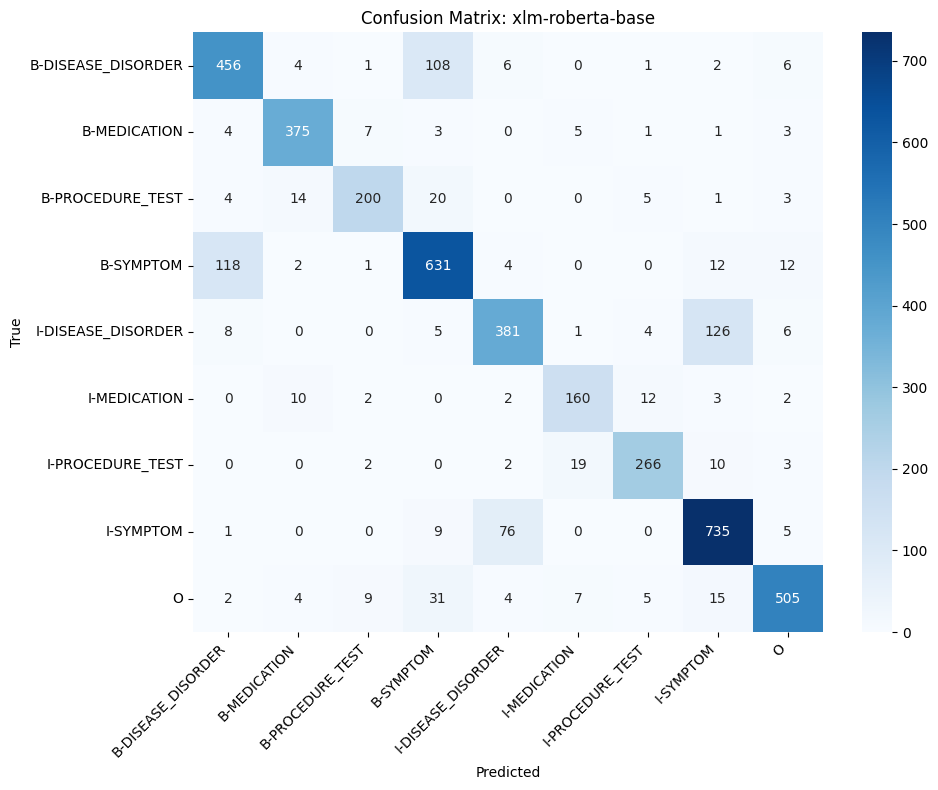



Processing: aubmindlab/bert-base-arabertv2
   ↳ Loading from: ./results_aubmindlab-bert-base-arabertv2/checkpoint-630


Map:   0%|          | 0/214 [00:00<?, ? examples/s]

/tmp/ipython-input-1732941361.py:93: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  temp_trainer = Trainer(


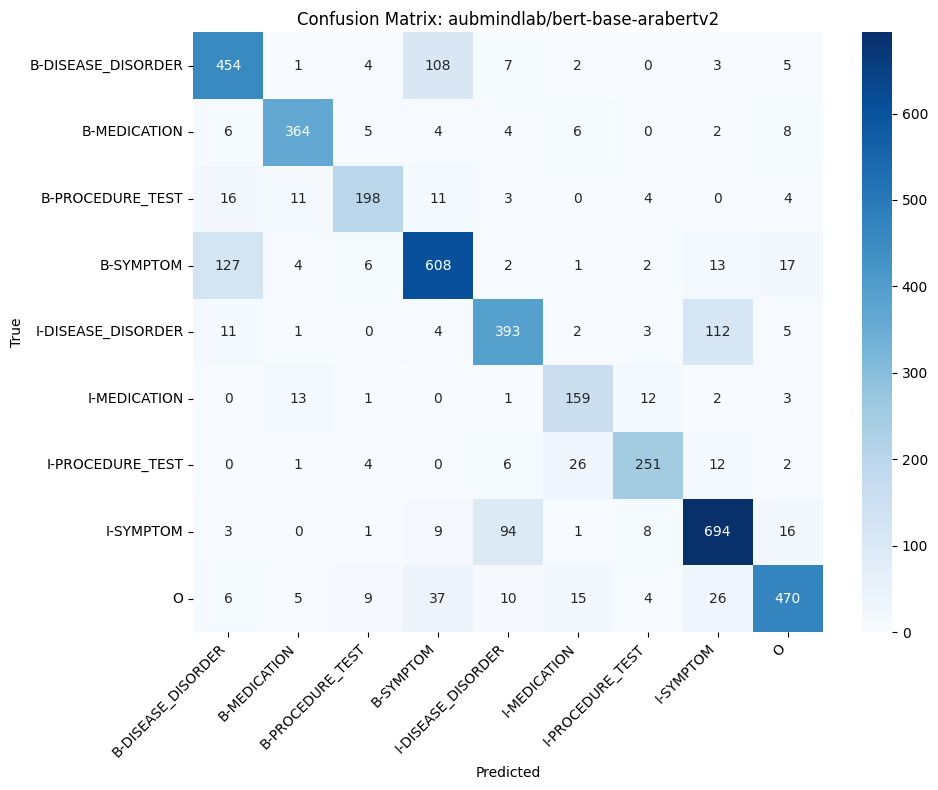



Processing: aubmindlab/araelectra-base-discriminator
   ↳ Loading from: ./results_aubmindlab-araelectra-base-discriminator/checkpoint-630


Map:   0%|          | 0/214 [00:00<?, ? examples/s]

/tmp/ipython-input-1732941361.py:93: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  temp_trainer = Trainer(


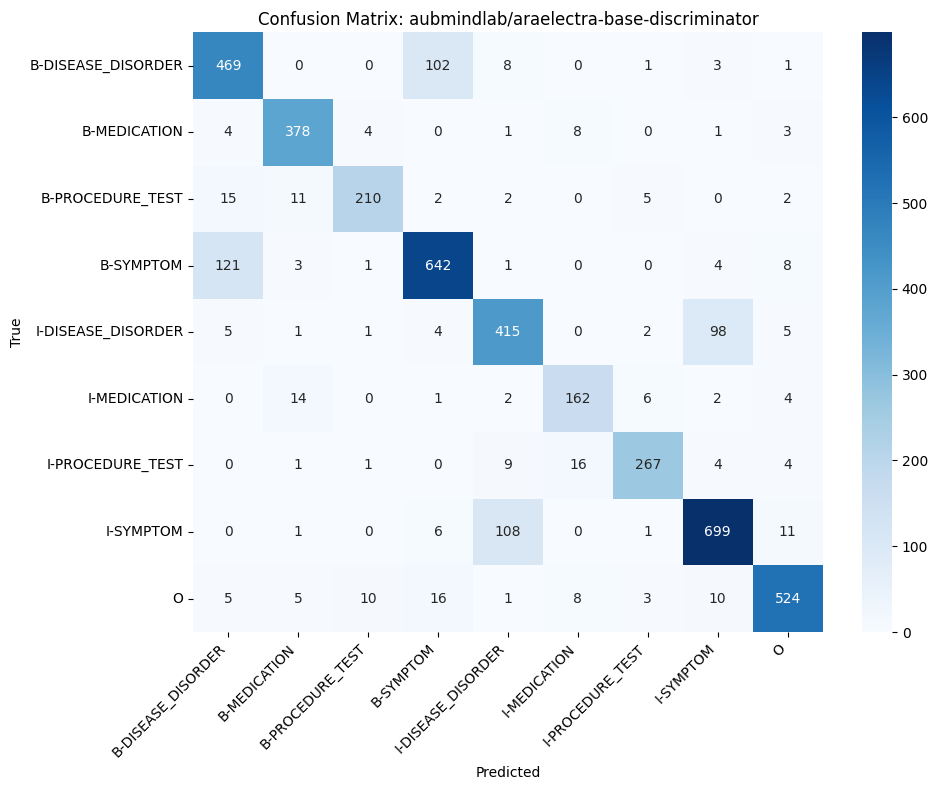



Processing: ahmedabdelali/bert-base-qarib
   ↳ Loading from: ./results_ahmedabdelali-bert-base-qarib/checkpoint-567


Map:   0%|          | 0/214 [00:00<?, ? examples/s]

/tmp/ipython-input-1732941361.py:93: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  temp_trainer = Trainer(


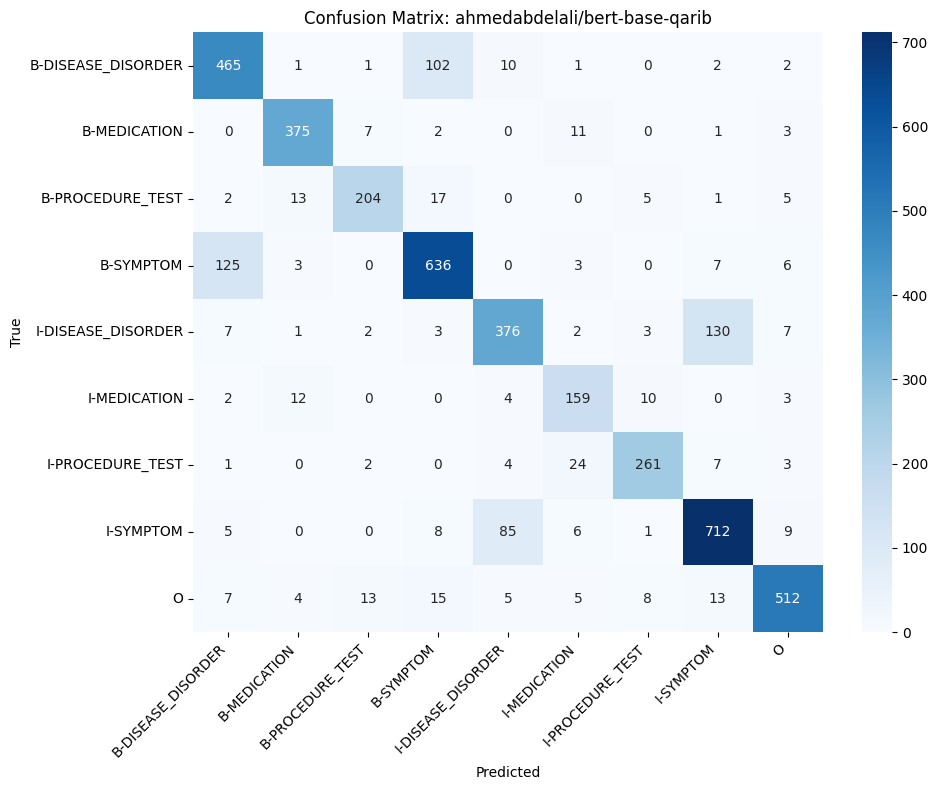



Processing: bert-base-multilingual-cased
   ↳ Loading from: ./results_bert-base-multilingual-cased/checkpoint-378


The tokenizer you are loading from './results_bert-base-multilingual-cased/checkpoint-378' with an incorrect regex pattern: https://huggingface.co/mistralai/Mistral-Small-3.1-24B-Instruct-2503/discussions/84#69121093e8b480e709447d5e. This will lead to incorrect tokenization. You should set the `fix_mistral_regex=True` flag when loading this tokenizer to fix this issue.


Map:   0%|          | 0/214 [00:00<?, ? examples/s]

/tmp/ipython-input-1732941361.py:93: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  temp_trainer = Trainer(


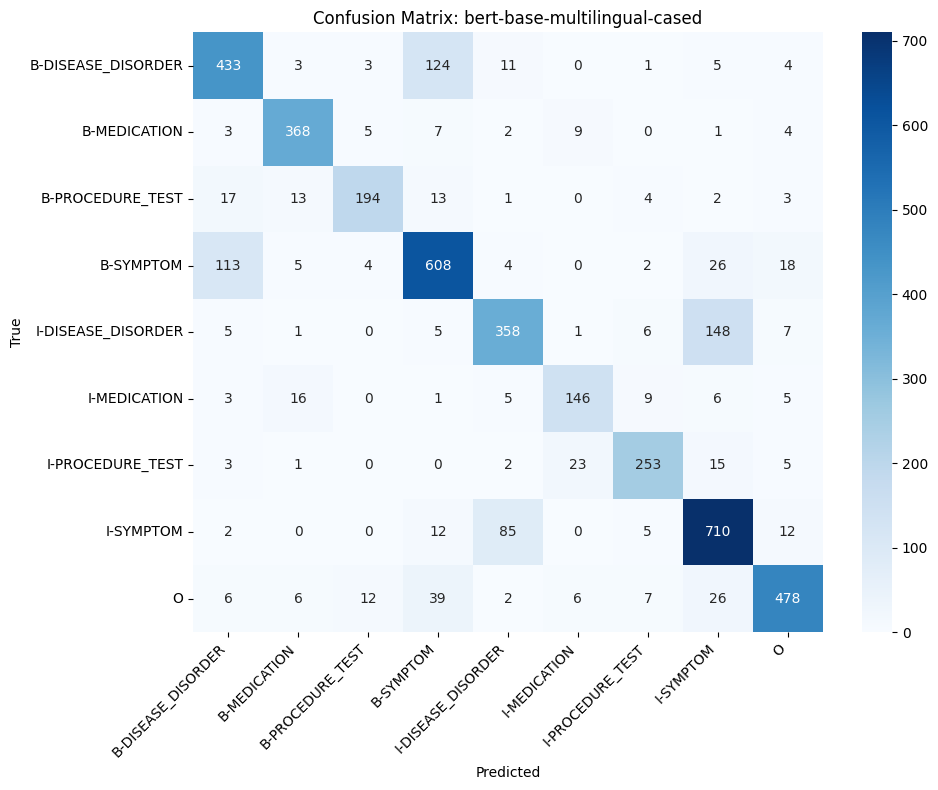

In [15]:
import os
import glob
import torch
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from transformers import AutoTokenizer, AutoModelForTokenClassification, Trainer, TrainingArguments
from sklearn.metrics import confusion_matrix

# 1. DISABLE WANDB GLOBALLY
os.environ["WANDB_DISABLED"] = "true"

model_candidates = [
    "xlm-roberta-base",
    "aubmindlab/bert-base-arabertv2",
    "aubmindlab/araelectra-base-discriminator",
    "ahmedabdelali/bert-base-qarib",
    "bert-base-multilingual-cased"
]

print(f"📊 Generating Confusion Matrices for {len(model_candidates)} models...\n")

for model_name in model_candidates:
    print(f"{'='*50}")
    print(f"Processing: {model_name}")
    print(f"{'='*50}")

    # Locate the model
    base_dir = f"./results_{model_name.replace('/', '-')}"

    if not os.path.exists(base_dir):
        print(f"⚠️  Skipping {model_name}: Directory not found.")
        continue

    checkpoints = glob.glob(f"{base_dir}/checkpoint-*")
    if not checkpoints:
        print(f"⚠️  Skipping {model_name}: No checkpoints found.")
        continue

    # Get latest checkpoint
    load_path = max(checkpoints, key=os.path.getmtime)
    print(f"   ↳ Loading from: {load_path}")

    try:
        # Load Model & Tokenizer
        tokenizer = AutoTokenizer.from_pretrained(load_path)
        model = AutoModelForTokenClassification.from_pretrained(load_path)

        # --- FIX 1: Use Full Alignment Logic (Required for 'labels' to exist) ---
        def tokenize_and_align_labels(examples):
            tokenized_inputs = tokenizer(
                examples['Tokenized_Text'],
                truncation=True,
                padding='max_length',
                max_length=512,
                is_split_into_words=True
            )

            all_labels = []
            for i, seq_labels in enumerate(examples['NER_Label_Sequence']):
                word_ids = tokenized_inputs.word_ids(batch_index=i)
                label_ids = []
                previous_word_idx = None
                for word_idx in word_ids:
                    if word_idx is None:
                        label_ids.append(-100)
                    elif word_idx != previous_word_idx:
                        label_ids.append(label2id[seq_labels[word_idx]])
                    else:
                        label_ids.append(-100)
                    previous_word_idx = word_idx
                all_labels.append(label_ids)

            tokenized_inputs["labels"] = all_labels
            return tokenized_inputs

        # --- FIX 2: remove_columns (Prevents "Unable to create tensor" error) ---
        test_ds_formatted = raw_test_dataset.map(
            tokenize_and_align_labels,
            batched=True,
            remove_columns=raw_test_dataset.column_names  # <--- CRITICAL: Deletes raw text columns
        )

        # Define Args
        temp_args = TrainingArguments(
            output_dir="./tmp_pred",
            per_device_eval_batch_size=16,
            report_to="none",
            remove_unused_columns=False
        )

        # Initialize Trainer
        temp_trainer = Trainer(
            model=model,
            args=temp_args,
            tokenizer=tokenizer
        )

        # Predict
        preds_output = temp_trainer.predict(test_ds_formatted)
        preds = np.argmax(preds_output.predictions, axis=2)
        true_labels = preds_output.label_ids

        # Flatten
        preds_flat = []
        labels_flat = []

        for i in range(len(preds)):
            for j in range(len(preds[i])):
                if true_labels[i][j] != -100:
                    preds_flat.append(id2label[preds[i][j]])
                    labels_flat.append(id2label[true_labels[i][j]])

        # Plot
        unique_labels = sorted(list(set(labels_flat + preds_flat)))
        cm = confusion_matrix(labels_flat, preds_flat, labels=unique_labels)

        plt.figure(figsize=(10, 8))
        sns.heatmap(cm, annot=True, fmt="d", xticklabels=unique_labels, yticklabels=unique_labels, cmap="Blues")
        plt.title(f"Confusion Matrix: {model_name}")
        plt.xlabel("Predicted")
        plt.ylabel("True")
        plt.xticks(rotation=45, ha='right')
        plt.tight_layout()
        plt.show()

    except Exception as e:
        print(f"❌ Error visualizing {model_name}: {e}")

    # Cleanup
    del model
    del tokenizer
    del temp_trainer
    torch.cuda.empty_cache()
    print("\n")